# Hyperparameter Tuning — Trial Results Analysis
Phân tích kết quả 29 trials từ quá trình fine-tune face recognition backbone với LoRA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

## 1. Load dữ liệu

In [2]:
df = pd.read_csv('trial_results.csv')
print(f'Số trials: {len(df)}')
df.head()

Số trials: 29


,trial,lr,weight_decay,lora_r,lora_dropout,warmup_epochs,margin_m2,final_loss,special_test,lfw_decrease,score
0,0,0.000118,0.036800,4,0.01,3,0.38,7.6187,0.8730,0.9753,2.7212
1,1,0.000255,0.000114,4,0.04,1,0.36,3.3169,0.8978,0.9643,2.7598
2,2,0.000135,0.000611,4,0.09,3,0.26,3.5686,0.8714,0.9746,2.7174
3,3,0.000163,0.003970,8,0.19,3,0.44,6.6488,0.8939,0.9794,2.7672
4,4,0.000101,0.000183,4,0.01,3,0.28,4.7795,0.8753,0.9760,2.7265


In [3]:
df.describe()

,trial,lr,weight_decay,lora_r,lora_dropout,warmup_epochs,margin_m2,final_loss,special_test,lfw_decrease,score
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,14.000000,0.000189,0.006529,19.310345,0.110000,2.034483,0.378966,4.168110,0.890790,0.968338,2.749900
std,8.514693,0.000129,0.009250,12.098121,0.050639,0.680481,0.072128,2.976114,0.011988,0.009772,0.025711
min,0.000000,0.000051,0.000114,4.000000,0.010000,1.000000,0.210000,0.582300,0.864400,0.943000,2.681900
25%,7.000000,0.000083,0.000782,8.000000,0.080000,2.000000,0.330000,1.388800,0.883000,0.964300,2.737100
50%,14.000000,0.000136,0.002740,16.000000,0.110000,2.000000,0.400000,3.568600,0.893100,0.971800,2.757900
75%,21.000000,0.000255,0.008120,32.000000,0.140000,2.000000,0.430000,6.648800,0.897800,0.974600,2.767200
max,28.000000,0.000499,0.036800,32.000000,0.200000,3.000000,0.500000,11.245700,0.909400,0.979400,2.793300


## 2. Trial tốt nhất

In [4]:
best = df.loc[df['score'].idxmax()]
print('=== BEST TRIAL ===')
print(best.to_string())

=== BEST TRIAL ===
trial            24.000000
lr                0.000083
weight_decay      0.002740
lora_r           32.000000
lora_dropout      0.080000
warmup_epochs     2.000000
margin_m2         0.430000
final_loss        4.827400
special_test      0.909400
lfw_decrease      0.974600
score             2.793300


## 3. Score theo từng trial

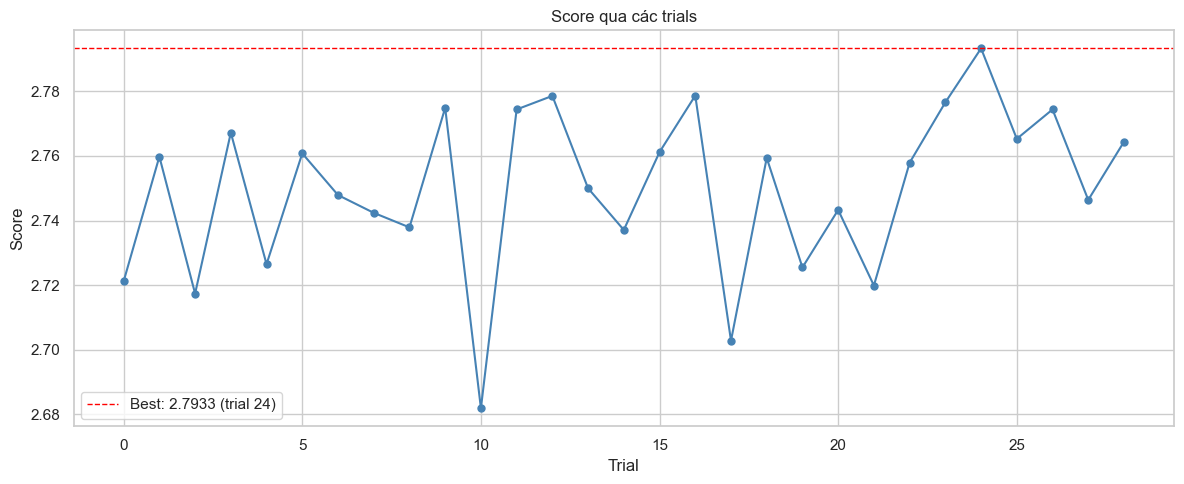

In [5]:
fig, ax = plt.subplots()
ax.plot(df['trial'], df['score'], marker='o', linewidth=1.5, markersize=5, color='steelblue')
ax.axhline(df['score'].max(), color='red', linestyle='--', linewidth=1, label=f"Best: {df['score'].max():.4f} (trial {df['score'].idxmax()})")
ax.set_xlabel('Trial')
ax.set_ylabel('Score')
ax.set_title('Score qua các trials')
ax.legend()
plt.tight_layout()
plt.show()

## 4. special_test và lfw_decrease theo trial

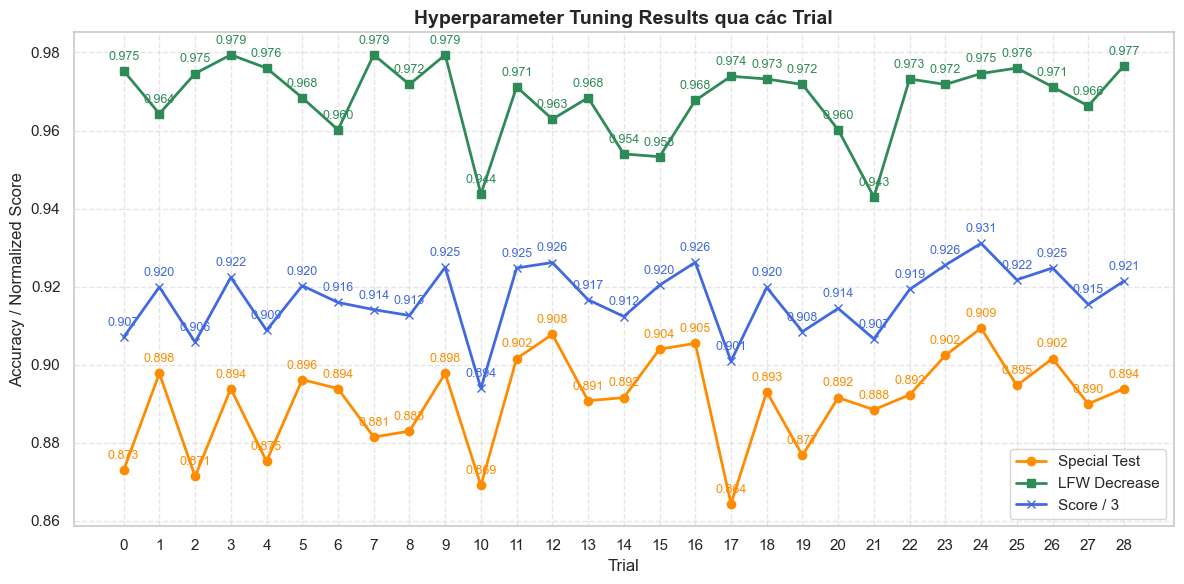

In [16]:
import matplotlib.pyplot as plt

# Tăng kích thước biểu đồ để các text không bị đè lên nhau
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# Vẽ các đường với label để hiển thị chú thích (legend)
axes.plot(df['trial'], df['special_test'], marker='o', color='darkorange', markersize=6, label='Special Test', linewidth=2)
axes.plot(df['trial'], df['lfw_decrease'], marker='s', color='seagreen', markersize=6, label='LFW Decrease', linewidth=2)
axes.plot(df['trial'], df['score']/3, marker='x', color='royalblue', markersize=6, label='Score / 3', linewidth=2)

# Hàm nhỏ để thêm text giá trị vào từng điểm
def add_labels(x, y, color):
    for i, j in zip(x, y):
        # xytext=(0, 8) đẩy text lên một chút để không đè vào marker
        axes.annotate(f"{j:.3f}", (i, j), textcoords="offset points", xytext=(0, 8), 
                      ha='center', fontsize=9, color=color)

# Hiển thị giá trị lên biểu đồ
add_labels(df['trial'], df['special_test'], 'darkorange')
add_labels(df['trial'], df['lfw_decrease'], 'seagreen')
add_labels(df['trial'], df['score']/3, 'royalblue')

# ÉP HIỂN THỊ ĐẦY ĐỦ CÁC TRIAL TRÊN TRỤC X
axes.set_xticks(df['trial'])

# Trang trí biểu đồ
axes.set_title('Hyperparameter Tuning Results qua các Trial', fontsize=14, fontweight='bold')
axes.set_xlabel('Trial', fontsize=12)
axes.set_ylabel('Accuracy / Normalized Score', fontsize=12)
axes.grid(True, linestyle='--', alpha=0.5) # Thêm lưới mờ để dễ nhìn
axes.legend(loc='best', fontsize=11) # Bật chú thích

plt.tight_layout()
plt.show()


## 5. Phân tích ảnh hưởng của Learning Rate

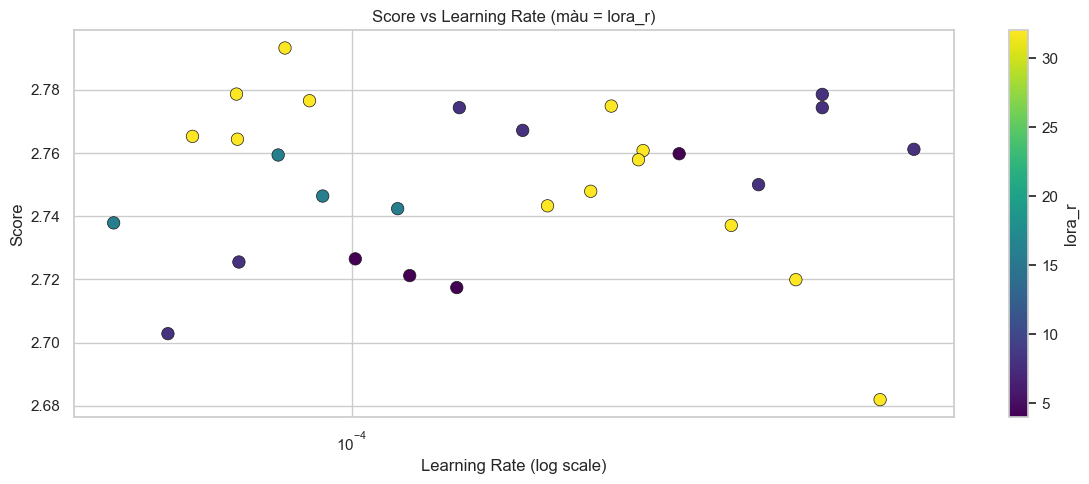

In [7]:
fig, ax = plt.subplots()
sc = ax.scatter(df['lr'], df['score'], c=df['lora_r'], cmap='viridis', s=80, edgecolors='k', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='lora_r')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)')
ax.set_ylabel('Score')
ax.set_title('Score vs Learning Rate (màu = lora_r)')
plt.tight_layout()
plt.show()

## 6. Ảnh hưởng của lora_r lên score

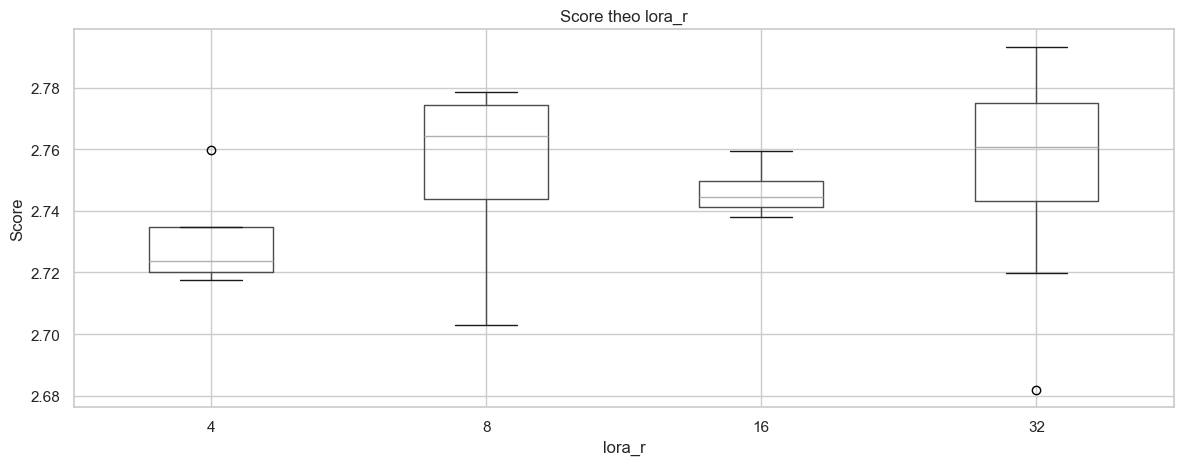

        count      mean       std     min       25%      50%       75%     max
lora_r                                                                        
4         4.0  2.731225  0.019412  2.7174  2.720250  2.72385  2.734825  2.7598
8         8.0  2.754263  0.027026  2.7028  2.743875  2.76420  2.774400  2.7786
16        4.0  2.746525  0.009259  2.7379  2.741275  2.74440  2.749650  2.7594
32       13.0  2.754000  0.029152  2.6819  2.743300  2.76080  2.774900  2.7933


In [8]:
fig, ax = plt.subplots()
df.boxplot(column='score', by='lora_r', ax=ax)
ax.set_title('Score theo lora_r')
ax.set_xlabel('lora_r')
ax.set_ylabel('Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('lora_r')['score'].describe())

## 7. Correlation heatmap giữa hyperparameters và score

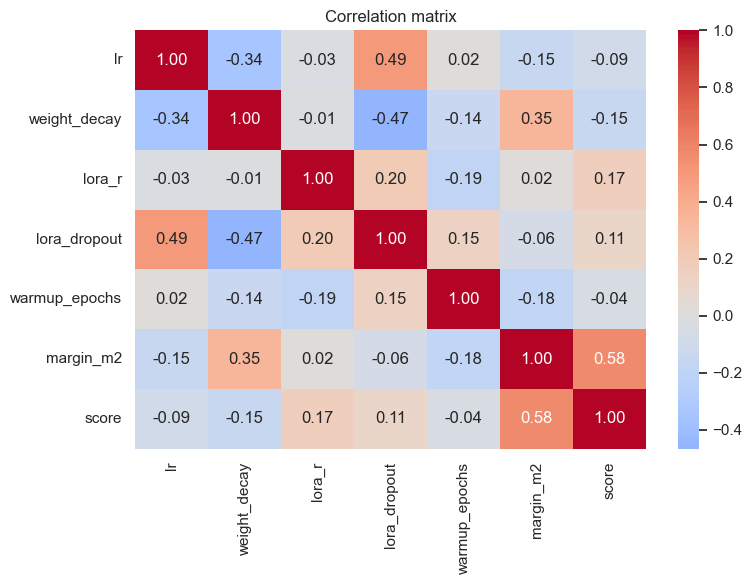

In [9]:
cols = ['lr', 'weight_decay', 'lora_r', 'lora_dropout', 'warmup_epochs', 'margin_m2', 'score']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.show()

## 8. Top 5 trials

In [10]:
top5 = df.nlargest(5, 'score')[['trial','lr','weight_decay','lora_r','lora_dropout',
                                  'warmup_epochs','margin_m2','final_loss','special_test','lfw_decrease','score']]
top5.reset_index(drop=True, inplace=True)
print('Top 5 trials theo score:')
top5

Top 5 trials theo score:


,trial,lr,weight_decay,lora_r,lora_dropout,warmup_epochs,margin_m2,final_loss,special_test,lfw_decrease,score
0,24,0.000083,0.002740,32,0.08,2,0.43,4.8274,0.9094,0.9746,2.7933
1,16,0.000072,0.011300,32,0.10,2,0.40,4.7485,0.9055,0.9677,2.7787
2,12,0.000384,0.001610,8,0.14,2,0.40,2.5297,0.9078,0.9629,2.7786
3,23,0.000089,0.002580,32,0.12,2,0.42,4.3629,0.9024,0.9718,2.7766
4,9,0.000210,0.000782,32,0.13,3,0.34,0.9627,0.8978,0.9794,2.7749


## 9. Final loss vs Score

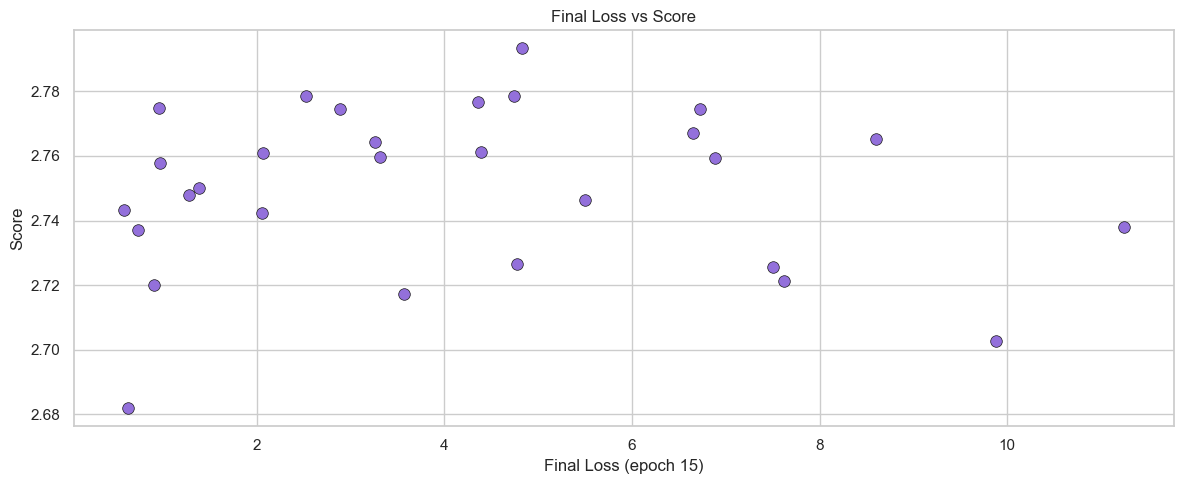

Pearson correlation (final_loss vs score): -0.039


In [11]:
fig, ax = plt.subplots()
ax.scatter(df['final_loss'], df['score'], s=70, edgecolors='k', linewidth=0.5, color='mediumpurple')
ax.set_xlabel('Final Loss (epoch 15)')
ax.set_ylabel('Score')
ax.set_title('Final Loss vs Score')
plt.tight_layout()
plt.show()

print(f"Pearson correlation (final_loss vs score): {df[['final_loss','score']].corr().iloc[0,1]:.3f}")